# Federal University of Bahia (UFBA)  
## Graduate Program in Geophysics (PPGEOF)  
### Research Group: LIGA - Laboratory of Innovation in Applied Geophysics  

---

**Notebook Title:** *FWI Conventional*  
**Author:** *Msc Student. Rômulo Barbosa*  
**Advisor:** *Prof.Dr. Peterson Nogueira Santos*  

**Course:** *Master Degree*

**Line of Research:** *Seismic Imaging*  

**Institution:** *Institute of Geosciences – IGEO/UFBA*  
**Date:** *05/10/2025*  

---

### Objectives  
- This tutorial shows an implementation of FWI by using Pylops.

---

### Description  

This notebook contains:  

- **Brief summary of what will be done:**  
  - FWI using the PyLops library.

- **Data or models used:**  
  - Marmousi true velocity model loaded from binary file (`model-t.bin`)
  - Marmousi inicial velocity model loaded from binary file (`model-inicial.bin`)  

- **Applied methodology:**  
  - Seismic data were generated using the true velocity model with a 2D acoustic wave equation operator (`AcousticWave2D`) from Pylops
  - Objective function applied were L2 Norm
e function applied were L2 Norm

# Importing Libraries

In [1]:
import copy
import numpy as np
from copy import deepcopy
from pylops.utils import *
from FWI import FWI_Multiscale
import matplotlib.pyplot as plt
from devito import configuration
from scipy.ndimage import gaussian_filter
from pylops.waveeqprocessing.twoway import ViscoAcousticWave2D
from utils import (plot_data, Frequency_spectrum, plot_freq_spectrum, create_mask_value, get_alfa_g)

configuration['log-level'] = 'ERROR'

## Initializing Model Parameters

The foundation of **Pylops** functionality lies in the use of operators, in this case, the 2D acoustic operator (**AcousticWave2D**). This operator wraps **DEVITO** objects, such as SeismicModel, which includes the velocity model, time step (dt), and other details and Geometry, which contains all the necessary geometry information, such as receiver and source coordinates.

By encapsulating these objects, users only need to focus on the parameters to be applied, rather than on how the underlying objects are built.

Below are the parameters required for creating the **AcousticWave2D** operator.

In [2]:
# Modelling parameters (in meters, seconds and Hz)
par = {
    'nx': 98,   'dx': 25,     'ox': 0.,
    'nz': 100,  'dz': 25,     'oz': 0.,
    'ns': 20,   'ds': 175,    'sz': 0.,
    'nr': 98,   'dr': 25,     'rz': 0.,
    'nt': 3000, 'dt': 0.002,   't0': 0.,
    'nw': 5,   'freq': 20}

shape = (par['nx'], par['nz'])
spacing = (par['dx'], par['dz'])
origin = (par['ox'], par['oz'])
src_type = 'Ricker' # or 'Ricker_Devito' if you want to use Devito Source
dtype = np.float32
space_order = 8
nbl = 50
witer = 10 # wolfe iterations

In [3]:
# Setting model velocity path
path_true_model="Petrophysics/vp_rho_smeaheia.npz"

# Loading model velocity
vp = np.load(path_true_model)['vp']
vp0 = gaussian_filter(vp, sigma = (5,5))

# Applying water layer
# msk = create_mask_value(vp, 1.52)
vp_min = np.min(vp)
vp_max = np.max(vp)

# Setting receivers positions
x_r = np.zeros((par['nr'], 2))
x_r[:, 0] = np.arange(par['nr']) * par['dr'] # receivers positions
x_r[:, 1] = par['rz']

# Setting source positions
model_domain_size = ((shape[0]-1)*spacing[0], (shape[1]-1)*spacing[1])
x_s = np.zeros((par['ns'], 2))
x_s[:,0] = np.linspace(0., model_domain_size[0], num=par['ns'])
x_s[:,1] = origin[1] + spacing[1] * 2

# Setting propagation time
tn = (np.arange(par['nt'])*par['dt'])[-1]

# Creating modelling operator
Dop = ViscoAcousticWave2D(shape=shape,origin=origin, spacing=spacing, vp=vp*1e3, b=1, qp=1, nbl=nbl, 
                          space_order=space_order,src_x=x_s[:,0], src_z=x_s[:,1], rec_x=x_r[:,0],
                          rec_z=x_r[:,1], t0=par['t0'], tn=par['nt'], src_type=src_type, f0=par['freq'],
                          dtype=dtype,op_name="fwd", dt=par['dt']*1e3, kernel='maxwell', time_order=1)

vp_true = deepcopy(vp)
vp_init = deepcopy(vp0) 

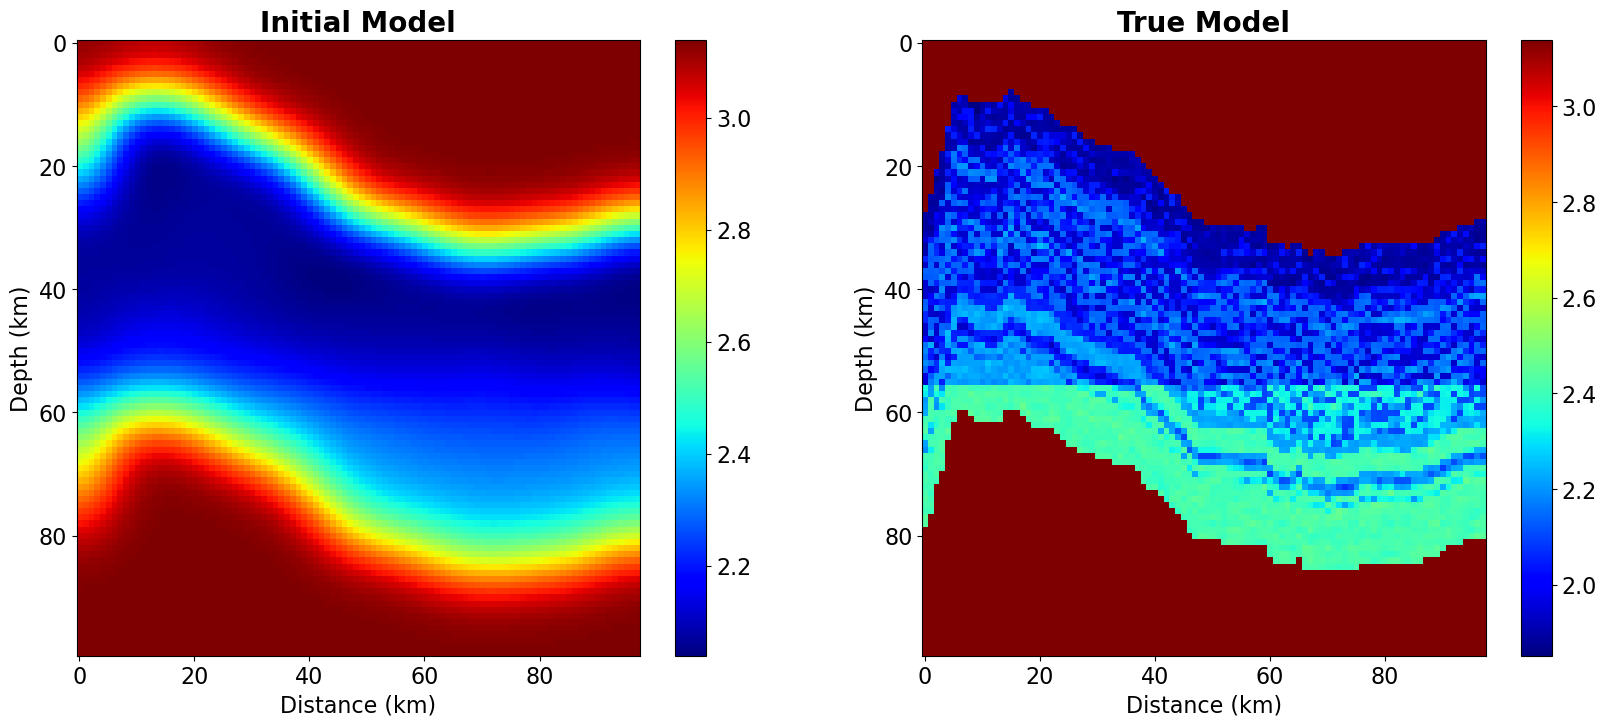

In [4]:
# Plotting velocity models
plt.figure(figsize=(20,8))
plt.subplot(1,2,1)
plt.imshow(vp_init.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('Initial Model', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(vp_true.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('True Model', fontsize=20, fontweight='bold')
plt.colorbar()

##  Generating Observed Data (Dobs)

Pylops performs forward propagation as follows:

$dobs = Dop * vptrue$, 

where $m$ represents the velocity value $vp$ em m/s.

In [5]:
dobs = Dop * vp_true

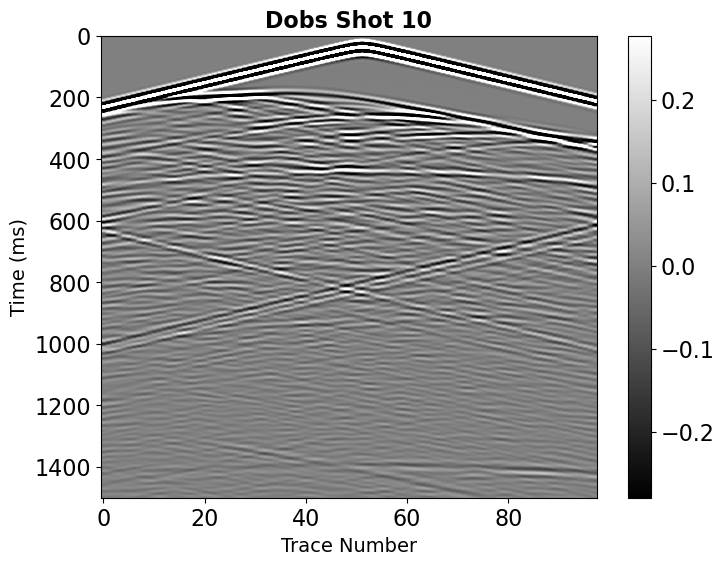

In [6]:
# Plotting Observed Data
shot_dobs = int(par['ns']/2)
plot_data(dobs,shot=shot_dobs, title=f'Dobs Shot {shot_dobs}')

# Conventional FWI

**Full-Waveform Inversion** is a geophysical technique used to refine subsurface models by inverting seismic data. 

To run FWI Conventional, you may set some parameters as:

- **iterations**: Number of iterations for each frequency.
- **vp_min**: Minimum value for the velocity model.
- **vp_max**: Maximum value for the velocity model.
- **water_layer**: Number of layers near the water region that should not be updated during inversion

Iteration  1
FO:  13234.99903406587



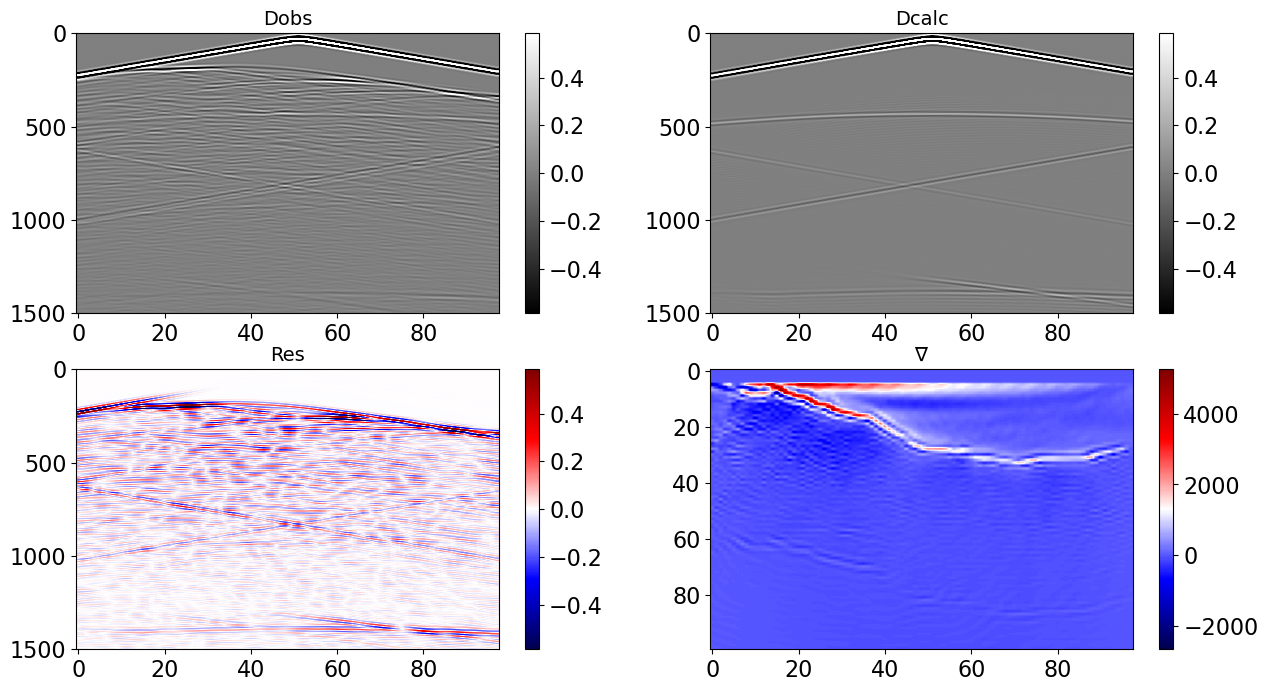

Iteration  2
FO:  11878.741819957388

Iteration  3
FO:  12178.268706081551

Iteration  4
FO:  10045.391416456667

Iteration  5
FO:  8545.343427930493

Iteration  6
FO:  7710.518143266934

Iteration  7
FO:  7261.167571300757

Iteration  8
FO:  7088.303716094262

Iteration  9
FO:  6956.109888918698

Iteration  10
FO:  6718.025214735215

Iteration  11
FO:  6453.8900233117165

Iteration  12
FO:  6189.185223211098

Iteration  13
FO:  5921.40261835375

Iteration  14
FO:  5613.179470787873

Iteration  15
FO:  5219.263841866632

Iteration  16
FO:  4789.388936469448

Iteration  17
FO:  4326.960303138738

Iteration  18
FO:  4015.3466624096036

Iteration  19
FO:  3855.890082773287

Iteration  20
FO:  3809.0489209781226

Iteration  21
FO:  3778.5252253257495

Iteration  22
FO:  3731.9231457710266

Iteration  23
FO:  3563.805384728155

Iteration  24
FO:  3436.1184777175076

Iteration  25
FO:  3366.607946846896

Iteration  26
FO:  3335.8074859141198

Iteration  27
FO:  3302.9022285028186

Iteration 

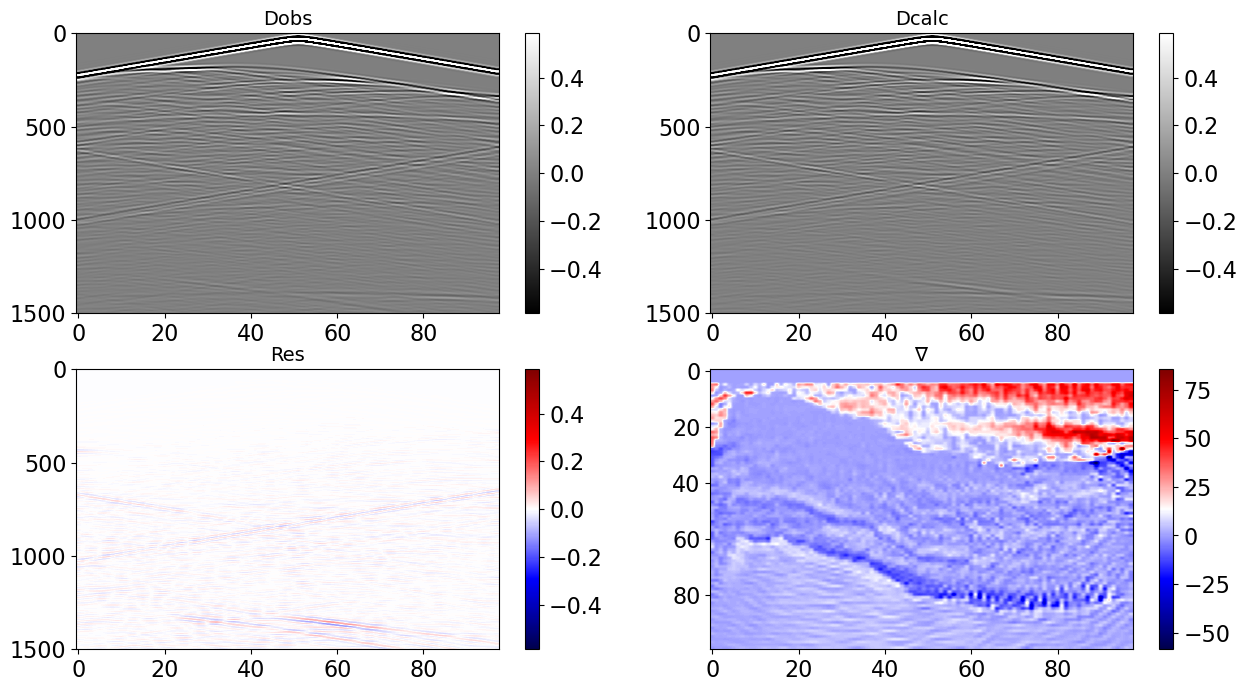

Done!


In [6]:
from numpy.linalg import norm
iterations = 150

history = np.zeros((iterations, 1)) # objective function

for iter in range(iterations):
    print("Iteration ", iter + 1)

    # generating calculated data
    dcalc = Dop * vp_init

    # calculating adjoint source
    res = dcalc - dobs

    # calculating objective function
    FO = .5*norm(res)**2
    print("FO: ", FO)
    print('')

    # calculating gradient
    grads = Dop.H*res

    # objective function storage
    history[iter] = FO
    
    grads[:,0:par['nw']] = 0.
    
    if iter == 0 or iter==range(iterations)[-1]:
        vmax = np.percentile(dobs, 99)
        plt.figure(figsize=(15,8))
        plt.subplot(2,2,1)
        plt.imshow(dobs[int(par['ns']/2)].T, aspect='auto',cmap='gray', vmin=-vmax, vmax=vmax)
        plt.title('Dobs', fontsize=14)
        plt.colorbar()
        plt.subplot(2,2,2)
        plt.imshow(dcalc[int(par['ns']/2)].T, aspect='auto',cmap='gray', vmin=-vmax, vmax=vmax)
        plt.title('Dcalc', fontsize=14)
        plt.colorbar()
        plt.subplot(2,2,3)
        plt.imshow(res[int(par['ns']/2)].T, aspect='auto',cmap='seismic', vmin=-vmax, vmax=vmax)
        plt.title('Res', fontsize=14)
        plt.colorbar()
        plt.subplot(2,2,4)
        plt.imshow(grads.T, aspect='auto',cmap='seismic')
        plt.title(r'$\nabla$', fontsize=14)
        plt.colorbar()
        plt.show()
    else:
        pass

    if iter == 0:
        alfa = .05 / np.max(grads)
    else:
        yk = grads - gradp
        sk = vp_init - vpp

        alfa = get_alfa_g(yk, sk)

    gradp = deepcopy(grads)
    vpp = deepcopy(vp_init)
   
    # update model
    dm = deepcopy(vp_init)
    vp_init = vp_init - alfa * grads
    vp_init[: ,0:par['nw']] = vp[:,0:par['nw']]

    np.putmask(vp_init, vp_init>vp_max, vp_max)
    np.putmask(vp_init, vp_init<vp_min, vp_min)

print('Done!')

## Plotting normalized objective function

Text(0.5, 1.0, 'Convergence')

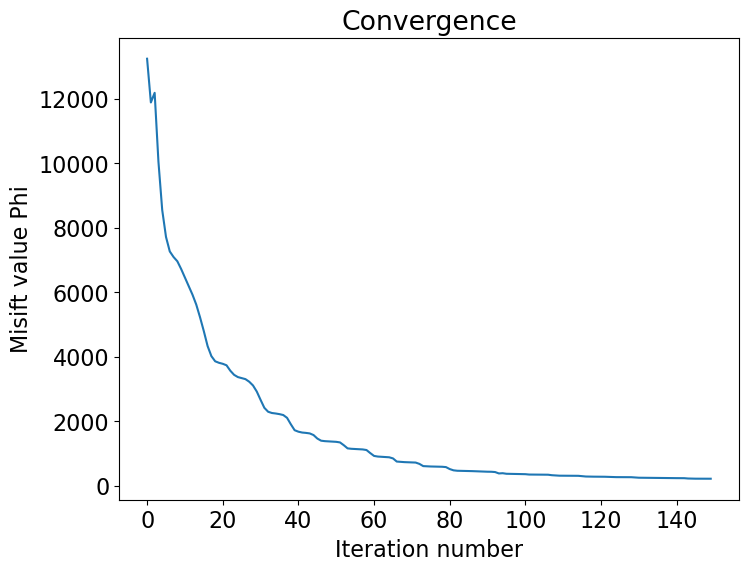

In [7]:
# Plot objective function decrease
plt.figure()
plt.plot(history)
plt.xlabel('Iteration number')
plt.ylabel('Misift value Phi')
# plt.vlines(x=2,ymin=history.min(),ymax=history.max(), color='red')
plt.title('Convergence')

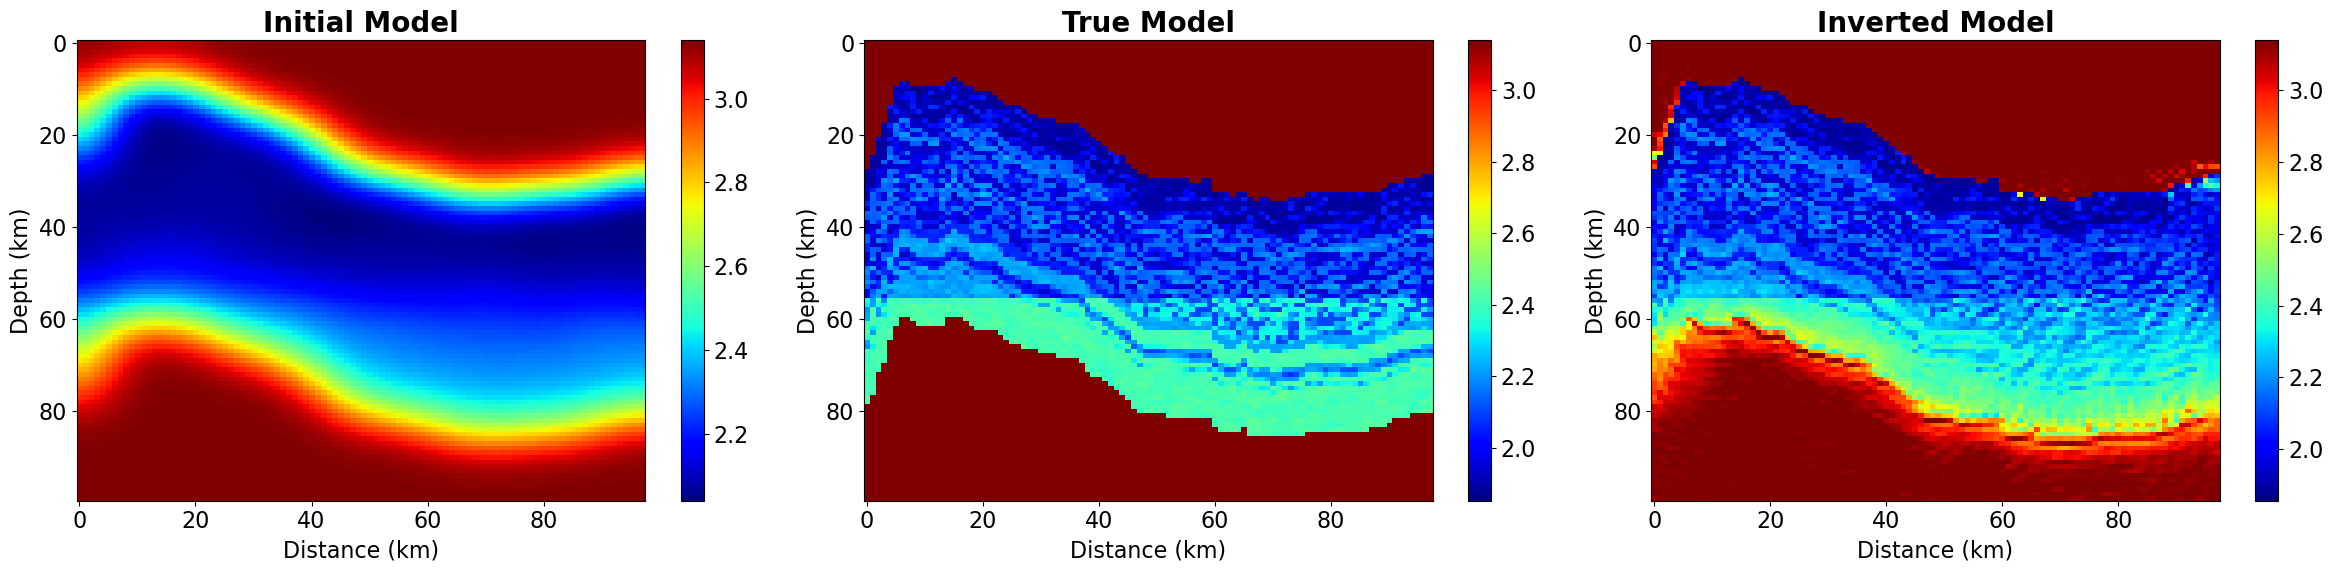

In [8]:
plt.figure(figsize=(24,6))
plt.subplot(1,3,1)
plt.imshow(vp0.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('Initial Model', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(vp.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('True Model', fontsize=20, fontweight='bold')
plt.colorbar()

plt.subplot(1,3,3)
plt.imshow(vp_init.T,aspect='auto',cmap='jet')
plt.ylabel('Depth (km)', fontsize=16)
plt.xlabel('Distance (km)',fontsize=16)
plt.title('Inverted Model', fontsize=20, fontweight='bold')
plt.colorbar()
plt.tight_layout()
# plt.savefig('results_equal_fortran.png', format='png')

In [10]:
# np.savez_compressed('vel_final.npz', arr_0=vp_init)